#Introduction

Walmart is an American multinational retail corporation that operates a chain of hypermarkets, discount department stores, and grocery stores from the United States serving more than 100 million customers worldwide.

**Business Problem:**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions.

They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assuming 100 million customers are equally divided into 50 million male and 50 million female).

#Importing Data and Python Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!gdown https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094 -O final_fg.csv

Downloading...
From: https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/293/original/walmart_data.csv?1641285094
To: /content/final_fg.csv
100% 23.0M/23.0M [00:00<00:00, 181MB/s]


#Data Exploration and Data Cleaning

In [ ]:
data = pd.read_csv('/content/final_fg.csv')
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
data.shape

(550068, 10)

There are 5,50,068 entries, and 10 columns.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [ ]:
data.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


Before proceeding with analysis, we check for:

1. Missing values

2. Correct data types

3. Proper categorization of variables

Categorical variables such as Gender, Age, City_Category, Stay_In_Current_City_Years, and Marital_Status should be treated as categorical for better analysis.

In [ ]:
data.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


There is no missing value in the dataset, thus being clean and appropriate for analysis

In [ ]:
cat_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status']

for col in cat_cols:
    data[col] = data[col].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  category
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(5), int64(4), object(1)
memory usage: 23.6+ MB


Converting these key variables into categorical type helps in better memory usage and easier grouping and visualisation.

#Non Graphical Analysis

In [ ]:
data['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


In [ ]:
data['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [ ]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
0,324731
1,225337


Key Observations:

1. Majority of customers are Male

2. Most customers belong to the 26 to 35 age group

3. A higher number of customers are Unmarried

In [ ]:
data.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


In [ ]:
data.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


#Outlier Detection

In [ ]:
data.describe()

,User_ID,Occupation,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,5.404270,9263.968713
std,1.727592e+03,6.522660,3.936211,5023.065394
min,1.000001e+06,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,20.000000,23961.000000


Observations:
1. Mean Purchase is almost 9264
2. Median (50%) = 8047
3. Minimum Purchase = 12
4. Maximum Purchase = 23961
5. Standard Deviation is almost 5023
6. Mean is higher than median which indicates it is right skewed distribution.
7. Maximum value is higher than mean, suggesting presence of outliers.
8. High standard deviation means wide variation in spending behaviour.

**Visual Detection using Boxplot**

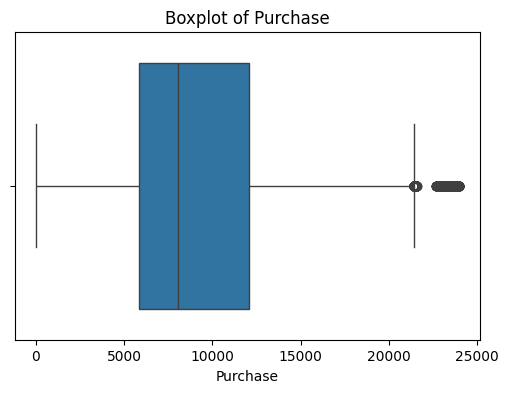

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['Purchase'])
plt.title("Boxplot of Purchase")
plt.show()

Observations:
1. There are several points beyond upper whisker, representing extremely high purchase values.
2. Most of the data lies within a compact range(around 5k to 12k).
3. Outliers are clearly present in the dataset occuring on the higher side or right tail.
4. In this case, those outliers on the higher side, indicates high spending customer and bulk or premium purchases.


**IQR Method**

In [ ]:
Q1 = data['Purchase'].quantile(0.25)
Q3 = data['Purchase'].quantile(0.75)
IQR = Q3 - Q1

outliers = data[(data['Purchase'] < (Q1 - 1.5*IQR)) |
                (data['Purchase'] > (Q3 + 1.5*IQR))]

len(outliers)

2677

Outliers detected are 2677, which shows they are in small portion compared to the size of the data(almost 550k). These are extreme high value transactions, and are not errors, but represent important aspects of this case.

#Univariate Analysis

**Visual Analysis - Univariate**

Univariate Analysis helps in understanding the distribution of individual variables in the dataset.
We analyse both continuous variable(purchase) and categorical variables(Gender,Age)


**Purchase Distribution**

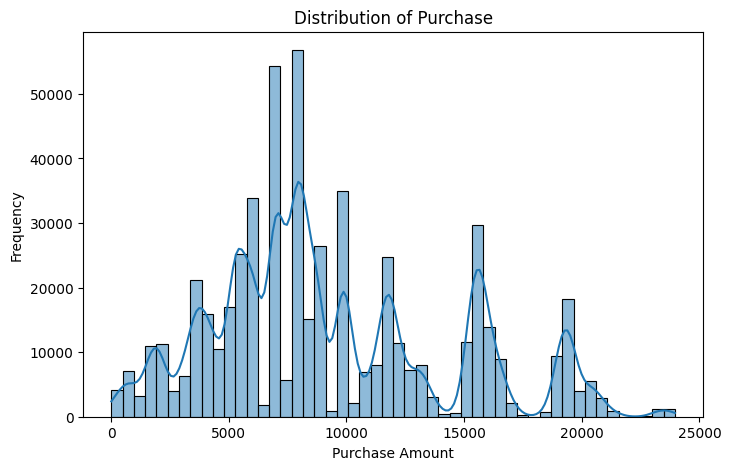

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Purchase'], bins=50, kde=True)
plt.title("Distribution of Purchase")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

Observations:

1. The distribution of purchase amount is right skewed.
2. Most transactions are concentrated between Rs. 5000 and Rs. 10000.
3. There are fewer transactions at higher purchase values.
4. A long tail extends towards higher value of upto Rs. 24000.
5. Purchase behaviour is not normally distributed.
6. Majority of customers make moderate purchases.

**Gender Distribution**

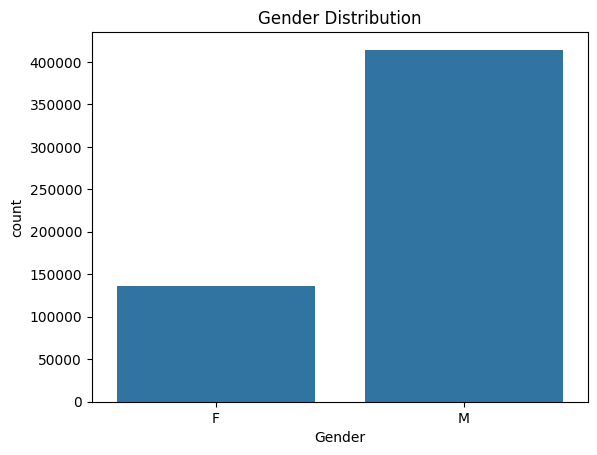

In [ ]:
sns.countplot(x='Gender', data=data)
plt.title("Gender Distribution")
plt.show()

Male customers are significantly higher than female customers, which means purchase behaviour analysis might get influenced by this imbalance.

**Age Distribution**

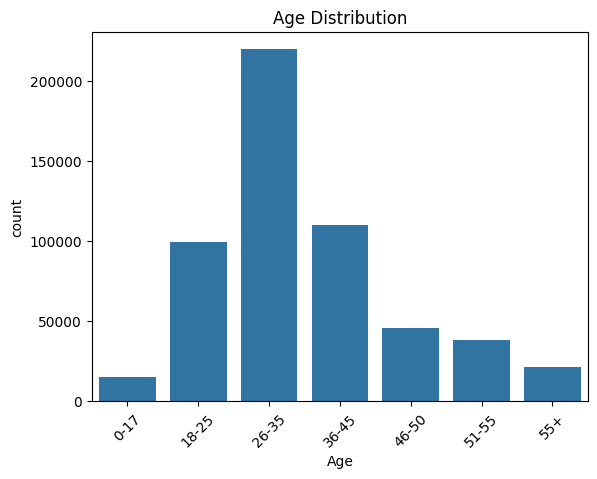

In [ ]:
sns.countplot(x='Age', data=data)
plt.title("Age Distribution")
plt.xticks(rotation=45)
plt.show()

Age group 26-35 has the highest number of customers, followed by age group of  36-45 and 18-25.

#Bivariate Analysis

**Visual Analysis - Bivariate**

Bivariate analysis helps in understanding relationship between two variables.

In this case, we analyse how purchase amount varies across different categories especially, gender vs purchase and age vs purchase.

**Gender Vs Purchase**

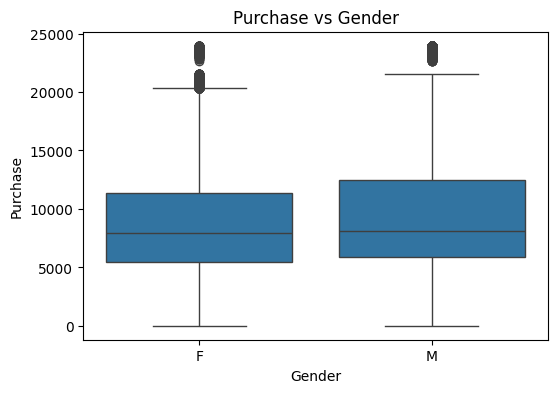

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Purchase', data=data)
plt.title("Purchase vs Gender")
plt.show()

Observations:
1. The purchase distribution for both males and females is quite similar
2. The median purchase for males is slightly higher than females
3. The spread (IQR) for males is slightly wider
4. Both genders show presence of outliers at higher purchase values
5. Male customers tend to spend slightly more per transaction than female customers, however, the overall spending pattern is largely similar across genders.

**Age vs Purchase**

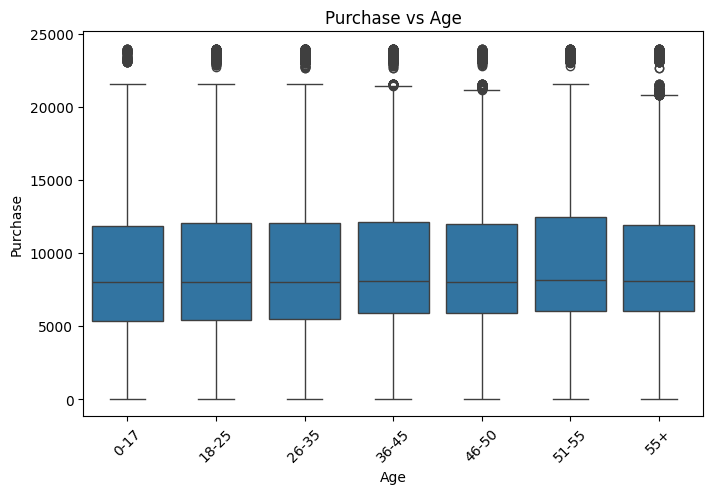

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Age', y='Purchase', data=data)
plt.title("Purchase vs Age")
plt.xticks(rotation=45)
plt.show()

Observations:
1. Purchase distribution is similar across all age groups, with most values lying between Rs. 5000 to Rs. 12000.
2. Median purchase is almost consistent across age categories.
3. Outliers are present in all age groups.
4. Age does not drastically change spending behaviour.

**Histogram Comparison**

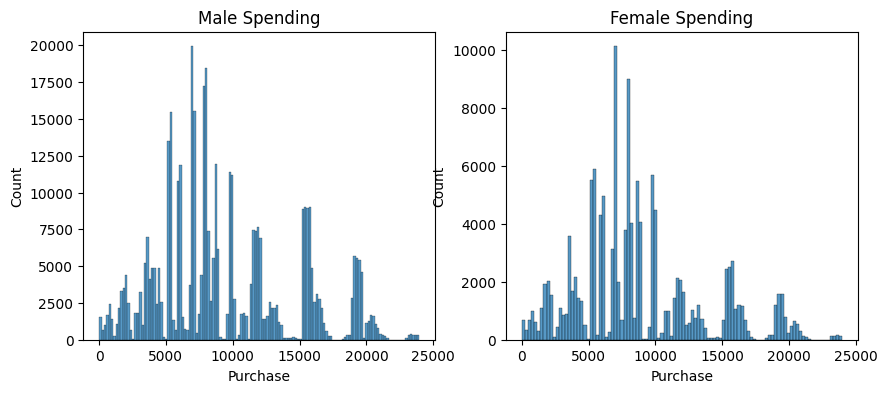

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data[data['Gender']=='M']['Purchase'])
plt.title("Male Spending")

plt.subplot(1,2,2)
sns.histplot(data[data['Gender']=='F']['Purchase'])
plt.title("Female Spending")

plt.show()

Observations:
1. Both male and female purchase distributions are right skewed meaning spending behaviour of males and females is similar in shape.
2. Most purchases for both groups lie between Rs. 5000 and Rs. 10000.
3. Male distribution shows slightly higher frequency at higher purchase values and slightly shifts towards the right.

Overall, bivariate analysis indicates that while spending patterns are broadly similar across gender and age, male customers tend to spend slightly more.

**Heatmap Analysis: Age and City_Category**

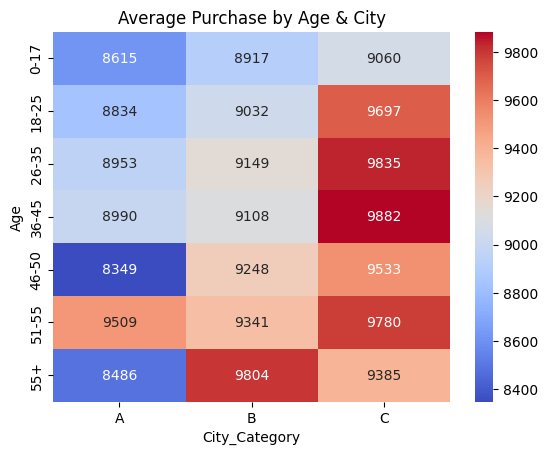

In [ ]:
pivot = pd.pivot_table(data, values='Purchase', index='Age', columns='City_Category',observed=True)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title("Average Purchase by Age & City")
plt.show()

Observations:
1. Customers in City C consistently show higher average spending across most age groups.
2. Age group 51 to 55 also shows high spending across all cities.
3. City A shows lower average purchase values compared to B and C.

#Statistics

Are women spending more money per transaction than men?

In [ ]:
avg_female = data[data['Gender'] == 'F']['Purchase'].mean()
avg_male = data[data['Gender'] == 'M']['Purchase'].mean()

print("Average Female Spending:", round(avg_female, 2))
print("Average Male Spending:", round(avg_male, 2))

Average Female Spending: 8734.57
Average Male Spending: 9437.53


Observations:
1. Average spending by females is almost 8734
2. Average spending by males is almost 9437

Inference:
1. Male customers spend more per transaction than female customers
2. The difference is noticeable but not extremely large.

Conclusion:
1. No, women do not spend more than men.
2. Male customers spend more on average per transaction compared to female customers.

#Confidence Interval & CLT

To estimate the population-level average spending, we use the Central Limit Theorem (CLT). With this, we construct Confidence Interval to estimate the range within which true population mean lies.

**Male vs Female**

In [ ]:
def confidence_interval(data):
    mean = data.mean()
    std = data.std()
    n = len(data)

    lower = mean - 1.96 * (std / np.sqrt(n))
    upper = mean + 1.96 * (std / np.sqrt(n))

    return (round(lower,2), round(upper,2))

ci_female = confidence_interval(data[data['Gender']=='F']['Purchase'])
ci_male = confidence_interval(data[data['Gender']=='M']['Purchase'])

print("Female CI:", ci_female)
print("Male CI:", ci_male)

Female CI: (np.float64(8709.21), np.float64(8759.92))
Male CI: (np.float64(9422.02), np.float64(9453.03))


Observations:
1. Confidence Interval for females is approximately (8709,8759)
2. Confidence Interval for males is approximately (9422,9453)
3. The confidence intervals for males and females do not overlap, hence there is a statistically significant difference between male and female spending.
4. Male customers spend significantly more than female customers.

**Statistical Test (T-Test for Gender Difference)**

In [ ]:
from scipy.stats import ttest_ind

male = data[data['Gender']=='M']['Purchase']
female = data[data['Gender']=='F']['Purchase']

t_stat, p_val = ttest_ind(male, female)

print("P-value:", round(p_val, 5))

P-value: 0.0


Observations:
1. The p-value is 0.0
2. As the p-value < 0.05, the difference in spending is statistically significant.
3. This confirms the results obtained from the confidence interval analysis.

**Married vs Unmarried**

In [ ]:
avg_married = data[data['Marital_Status'] == 1]['Purchase'].mean()
avg_unmarried = data[data['Marital_Status'] == 0]['Purchase'].mean()

print("Average Married Spending:", round(avg_married, 2))
print("Average Unmarried Spending:", round(avg_unmarried, 2))

Average Married Spending: 9261.17
Average Unmarried Spending: 9265.91


Observations:

With average spending of married and unmarried being approx 9261 and 9265 respectively, we can say the difference in average spending is very small and both groups show similar spending behaviour.


In [ ]:
ci_married = confidence_interval(data[data['Marital_Status'] == 1]['Purchase'])
ci_unmarried = confidence_interval(data[data['Marital_Status'] == 0]['Purchase'])

print("Married CI:", ci_married)
print("Unmarried CI:", ci_unmarried)

Married CI: (np.float64(9240.46), np.float64(9281.89))
Unmarried CI: (np.float64(9248.62), np.float64(9283.2))


Observations:
1. Confidence interval for married customer is almost (9240,9281) and for unmarried is (9248,9283).
2. The Confidence intervals overlap significantly which means there is no statistically significant difference.
3. Married and unmarried customers exhibit similar spending behaviour with no significant difference.

**Age-wise Analysis (Average Spending by Age Group)**

In [ ]:
data.groupby('Age', observed=True)['Purchase'].mean()

,Purchase
Age,
0-17,8933.464640
18-25,9169.663606
26-35,9252.690633
36-45,9331.350695
46-50,9208.625697
51-55,9534.808031
55+,9336.280459


Observations:
1. Age group 51 to 55 has the highest average spending of almost 9535
2. This is followed by 55+ age group (approx. 9336) & 36 to 45 age bracket (approx.9331)
3. Lowest was in the youngest segment of 0 to 17, with almost 8933.


**Confidence Intervals for Age Groups**

In [ ]:
age_groups = data['Age'].unique()

for age in age_groups:
    ci = confidence_interval(data[data['Age'] == age]['Purchase'])
    print(f"Age {age} CI:", ci)

Age 0-17 CI: (np.float64(8851.95), np.float64(9014.98))
Age 55+ CI: (np.float64(9269.3), np.float64(9403.26))
Age 26-35 CI: (np.float64(9231.73), np.float64(9273.65))
Age 46-50 CI: (np.float64(9163.08), np.float64(9254.17))
Age 51-55 CI: (np.float64(9483.99), np.float64(9585.63))
Age 36-45 CI: (np.float64(9301.67), np.float64(9361.03))
Age 18-25 CI: (np.float64(9138.41), np.float64(9200.92))


Observations:
1. Each age group has a narrow confidence interval, indicating stable estimates. Example: 26 to 35 with (9232, 9274) and 51 to 55 with (9484, 9586).
2. Confidence intervals across age groups slightly overlap.
3. Although differences exist in average spending, they are not extremely large across age groups.
4. The 51 to 55 age group still stands out as the highest spending segment.
5. Spending behavior across age groups is relatively consistent.

#Final Insights

**Gender-based Insights**
1. Male customers spend more per transaction than female customers.
2. The difference is statistically significant (non-overlapping confidence intervals).
3. However, the overall spending pattern is similar across genders.

**Marital Status Insights**
1. Married and unmarried customers show very similar spending behaviour.
2. Confidence intervals overlap significantly.
3. Marital status does not play a major role in influencing spending.

**Age-based Insights**
1. Customers aged 51 to 55 are the highest spenders.
2. Age groups 36 to 55 show relatively higher spending levels.
3. Younger customers (below 25) spend comparatively less.
4. However, differences across age groups are not very drastic.

**Purchase Behavior Insights**
1. Most purchases lie in the range Rs. 5000 to Rs. 10000.
2. The distribution is right-skewed.
3. A small number of customers make very high-value purchases.

**CLT & Confidence Interval Insights**
1. Sample means are reliable estimates of population means.
2. Confidence intervals help in understanding true population behaviour.
3. Gender difference in spending is statistically significant.
4. Marital status and age differences are less pronounced.

#Business Recommendations

**Target High-Spending Age Group**
1. Focus marketing campaigns on customers aged 36 to 55.
2. Especially target 51 to 55 age group, as they spend the most.

**Gender-based Strategy**
1. Since males spend more, promote premium and high-value products.
2. Avoid heavy gender-based segmentation as patterns are similar.

**Personalized Marketing**
1. Use customer purchase history for personalised recommendations.
2. Focus on behaviour rather than just demographics.

**Product Strategy**
1. Promote products in the Rs. 5000 to Rs. 10000 range, as most purchases fall here.
2. Introduce premium options for high-spending customers.

**Customer Segmentation**
1. Segment customers based on: Spending behaviour and Purchase frequency not just demographic factors.